REAL STATE ANALYSIS
:PREDICTING HOUSE PRICE USING PROPERTY AND LOCATION FEATURES


**Problem Understanding**

Predicting house prices is challenging because real estate data is often incomplete, inconsistent, and influenced by many factors such as property size, amenities, location, and market conditions. Traditional methods struggle with messy data and dynamic market trends, making accurate estimation difficult.
*italicised text*

**Target Definition**

*The goal is to build a robust machine learning model that can predict house prices using property and location features. This involves cleaning and preprocessing data, engineering meaningful features, training predictive models, and ensuring accuracy, scalability, and interpretability to support real estate decision-making.*

In [1]:
import kagglehub
path = kagglehub.dataset_download("zafarali27/house-price-prediction-dataset")

Using Colab cache for faster access to the 'house-price-prediction-dataset' dataset.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA COLLECTION

In [3]:
dt = pd.read_csv("/kaggle/input/house-price-prediction-dataset/House Price Prediction Dataset.csv")

In [4]:
dt.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [5]:
dt.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


In [6]:
df = pd.read_csv("/kaggle/input/house-price-prediction-dataset/House Price Prediction Dataset.csv")
print(df.to_string())

        Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition Garage   Price
0        1  1360         5          4       3       1970  Downtown  Excellent     No  149919
1        2  4272         5          4       3       1958  Downtown  Excellent     No  424998
2        3  3592         2          2       3       1938  Downtown       Good     No  266746
3        4   966         4          2       2       1902  Suburban       Fair    Yes  244020
4        5  4926         1          4       2       1975  Downtown       Fair    Yes  636056
5        6  3944         1          2       1       1906     Urban       Poor     No   93262
6        7  3671         1          1       2       1948     Rural       Poor    Yes  448722
7        8  3419         2          4       1       1925  Suburban       Good    Yes  594893
8        9   630         2          2       1       1932     Rural       Poor    Yes  652878
9       10  2185         3          3       1       2000  Downtown    

CONVERTING THE DATA TO SAME RANGE

In [13]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df_to_scale = dt.copy()
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_to_scale.select_dtypes(include=['float64','int64']))
df_scaled = pd.DataFrame(scaled_data, columns=df_to_scale.select_dtypes(include=['float64','int64']).columns)
print(df_scaled.to_string())

            Id      Area  Bedrooms  Bathrooms  Floors  YearBuilt     Price
0     0.000000  0.235024      1.00   1.000000     1.0   0.569106  0.143953
1     0.000500  0.861589      1.00   1.000000     1.0   0.471545  0.459459
2     0.001001  0.727353      0.25   0.333333     1.0   0.308943  0.286501
3     0.001501  0.133295      0.75   0.333333     0.5   0.016260  0.260050
4     0.002001  0.986312      0.00   1.000000     0.5   0.609756  0.669750
5     0.002501  0.797476      0.00   0.333333     0.0   0.048780  0.066428
6     0.003002  0.743217      0.00   0.000000     0.5   0.390244  0.484062
7     0.003502  0.692340      0.25   1.000000     0.0   0.203252  0.630092
8     0.004002  0.038994      0.25   0.333333     0.0   0.260163  0.685796
9     0.004502  0.429436      0.50   0.666667     0.0   0.813008  0.369122
10    0.005003  0.212180      0.00   1.000000     0.5   0.382114  0.686564
11    0.005503  0.582950      0.75   1.000000     1.0   0.634146  0.113687
12    0.006003  0.591803 

DATA CLEANING

for duplicate values

In [19]:
print(dt.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
1995    False
1996    False
1997    False
1998    False
1999    False
Length: 2000, dtype: bool


removing duplicate values


In [21]:
dt=dt.drop_duplicates()


for missing values

In [22]:
print("Missing values before dropping:")
print(dt.isnull().sum())
initial_rows = dt.shape[0]
dt = dt.dropna()
final_rows = dt.shape[0]
print(f"\nDataFrame shape before dropping NaNs: ({initial_rows}, {dt.shape[1]})")
print(f"DataFrame shape after dropping NaNs: ({final_rows}, {dt.shape[1]})")
if initial_rows == final_rows:
    print("No missing values were found or dropped.")
else:
    print(f"{initial_rows - final_rows} rows with missing values were dropped.")

Missing values before dropping:
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

DataFrame shape before dropping NaNs: (2000, 10)
DataFrame shape after dropping NaNs: (2000, 10)
No missing values were found or dropped.


for inconsistencies

In [23]:
print(dt.isnull().sum())

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [24]:
dt.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

accesing null values


In [25]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         2000 non-null   int64  
 1   Area       2000 non-null   float64
 2   Bedrooms   2000 non-null   int64  
 3   Bathrooms  2000 non-null   int64  
 4   Floors     2000 non-null   int64  
 5   YearBuilt  2000 non-null   int64  
 6   Location   2000 non-null   object 
 7   Condition  2000 non-null   object 
 8   Garage     2000 non-null   object 
 9   Price      2000 non-null   float64
dtypes: float64(2), int64(5), object(3)
memory usage: 156.4+ KB


EDA (EXPLORATORY DATA ANALYSIS) WITH INSIGHTS

In [26]:
import scipy.stats as stats
dt['Area'],  parameters = stats.boxcox(dt['Area'])
dt['Price'],  parameters = stats.boxcox(dt['Price'])

for area


<Axes: xlabel='Area', ylabel='Density'>

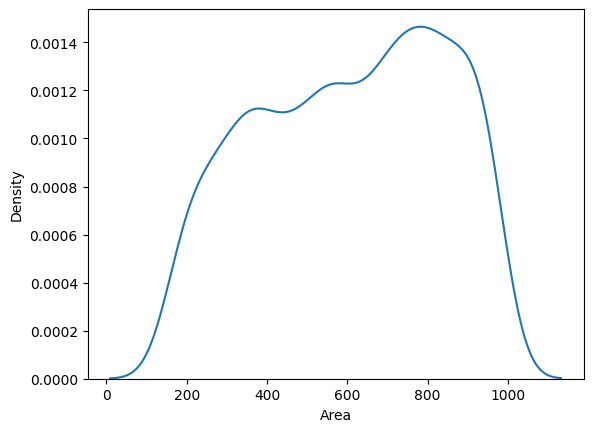

In [28]:
import seaborn as sns
sns.kdeplot(dt['Area'])

for price

<Axes: xlabel='Price', ylabel='Density'>

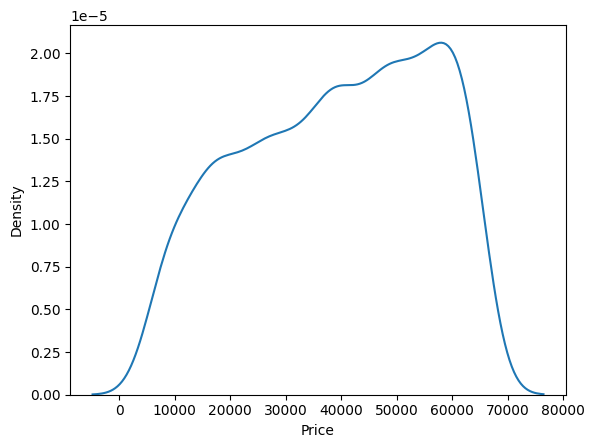

In [29]:
sns.kdeplot(dt['Price'])

DATA SPLITING

In [30]:
X = dt.drop('Price',axis=1)
y = dt['Price']

In [28]:
X.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
0,1,349.574235,5,4,3,1970,Downtown,Excellent,No
1,2,858.606266,5,4,3,1958,Downtown,Excellent,No
2,3,749.620866,2,2,3,1938,Downtown,Good,No
3,4,266.819478,4,2,2,1902,Suburban,Fair,Yes
4,5,959.842928,1,4,2,1975,Downtown,Fair,Yes


In [31]:
X.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
1995,1996,979.362496,5,4,3,1923,Suburban,Poor,No
1996,1997,665.323478,5,2,1,2019,Suburban,Poor,Yes
1997,1998,291.271828,5,1,2,1903,Rural,Poor,No
1998,1999,833.322498,3,1,2,1936,Urban,Excellent,Yes
1999,2000,655.561453,5,1,3,1903,Suburban,Fair,No


TRAIN TEST-SPLIT

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

3 regression model

In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
X_encoded = pd.get_dummies(X, columns=['Location', 'Condition', 'Garage'], drop_first=True)
X_encoded = X_encoded.drop('Id', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

MODEL-1: LINEAR REGRESSION

In [37]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print(f"Linear Regression MSE: {mean_squared_error(y_test, lr_pred)}")
print(f"Linear Regression R2 Score: {r2_score(y_test, lr_pred)}")

Linear Regression MSE: 291633037.9852873
Linear Regression R2 Score: -0.005891534981378621


MODEL-2: DECISION TREE REGRESSION

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_dt = GridSearchCV(estimator=DecisionTreeRegressor(random_state=42), param_grid=param_grid_dt, cv=3, n_jobs=-1, verbose=2)
grid_search_dt.fit(X_train, y_train)
best_dt_model = grid_search_dt.best_estimator_
print(f"Best parameters found for Tuned Decision Tree: {grid_search_dt.best_params_}")
print(f"Best cross-validation score for Tuned Decision Tree: {grid_search_dt.best_score_}")
best_dt_pred = best_dt_model.predict(X_test)
print(f"Tuned Decision Tree MSE: {mean_squared_error(y_test, best_dt_pred)}")
print(f"Tuned Decision Tree R2 Score: {r2_score(y_test, best_dt_pred)}")

Fitting 3 folds for each of 45 candidates, totalling 135 fits
Best parameters found for Tuned Decision Tree: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best cross-validation score for Tuned Decision Tree: -0.1338142767819297
Tuned Decision Tree MSE: 307104200.9221169
Tuned Decision Tree R2 Score: -0.05925418532437421


MODEL-3: RANDOM FOREST REGRESSION

In [40]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print(f"Random Forest MSE: {mean_squared_error(y_test, rf_pred)}")
print(f" Random Forest R2 Score: {r2_score(y_test, rf_pred)}")

Random Forest MSE: 314831420.90090185
 Random Forest R2 Score: -0.08590667030788612


HYPERPARAMETRE TUNING FOR ATLEAST ONE MODEL

 RANDOM FOREST REGRESSION

In [41]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2'], }
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
best_rf_model = grid_search.best_estimator_
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")
best_rf_pred = best_rf_model.predict(X_test)
print(f"Tuned Random Forest MSE: {mean_squared_error(y_test, best_rf_pred)}")
print(f"Tuned Random Forest R2 Score: {r2_score(y_test, best_rf_pred)}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters found: {'max_features': 'sqrt', 'n_estimators': 200}
Best cross-validation score: -0.03569606988931703
Tuned Random Forest MSE: 314128432.4593636
Tuned Random Forest R2 Score: -0.08348194460664793


MODEL EVALUATION, COMPARISION AND FINAL REGRESSION

As we know MSE is the statistical measure used in regression, machine learning, and signal processing to evaluate prediction accuracy.
and R² score (also called the coefficient of determination) is a statistical measure that tells you how well your regression model explains the variability of the target variable.
Therefore we can compare the MSE and R2 score values of all three models and the least values is of Linear Regression



MODEL SAVING USING PICKLE

In [42]:
import pickle
model_path = 'dt_model.pkl'
with open(model_path, 'wb') as file:
    pickle.dump(rf_model , file)
    print("Model saved successfully")

Model saved successfully
